In [265]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.integrate import quad
import os

def lennard_jones(r, epsilon, sigma):
    return 4 * epsilon * ((sigma / r)**12 - (sigma / r)**6)

def integrand(r, T, epsilon, sigma):
    beta = 1 / T
    u_r = lennard_jones(r, epsilon, sigma)
    return (1 - np.exp(-beta * u_r)) * r**2

def pressure_lj(T, epsilon, sigma, n):
    r_min = 0
    r_max = np.inf
    integral, error = quad(integrand, r_min, r_max, args=(T, epsilon, sigma))
    return n * T + 6 * np.pi * n**2 * T * integral / 3, 6 * np.pi * n**2 * T * error

def lennard_jones_cut(r, epsilon, sigma):
    if r > sigma:
        return 4 * epsilon * ((sigma / r)**12 - (sigma / r)**6)
    else:
        return np.inf

def integrand_cut(r, T, epsilon, sigma):
    beta = 1 / T
    u_r = lennard_jones_cut(r, epsilon, sigma)
    return (1 - np.exp(-beta * u_r)) * r**2

def pressure_lj_cut(T, epsilon, sigma, n):
    # r_min = 0.001 * sigma
    r_min = 0
    r_max = np.inf
    integral, error = quad(integrand_cut, r_min, r_max, args=(T, epsilon, sigma))
    return n * T + 6 * np.pi * n**2 * T * integral / 3, 6 * np.pi * n**2 * T * error / 3

def vdw(T, epsilon, sigma, n):
    return n * T / (1 - 2 * n * np.pi * sigma ** 3 / 3) - 2 * np.pi * sigma**3 * 4 * epsilon * n**2 / 3

In [266]:
0.2**12-0.2**6

-6.399590400000002e-05

In [267]:
def rho(n, r):
    return 4 * n * np.pi * r**3 / 3

pressures = []
rs = []
energies = []
# eps = [0, 0.1, 0.25, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5]
# eps = [0, 0.04, 0.08, 0.12, 0.16, 0.2, 0.25, 0.3, 0.5, 1, 1.5, 2, 0, 0.04, 0.08, 0.12, 0.16, 0.2, 0.25, 0.3, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5]
dirs = []
epsilons = []
steps = []
p_lj_cuts = []
p_ljs = []
timeLines = []
dts = []
# T_STOP = 50.0

i = 0
for d in os.listdir('.'):
    if os.path.isdir(d) and '20250907_215000' <= d[:15] <= '20250907_240000':
        dirs.append(d)
        r = float(d.split('r')[-1])
        rs.append(r)
        fs = os.listdir(os.path.join('.', d))
        assert "mean_v2.npy" in fs and "pressure.npy" in fs, f"Missing files in {d}"
        pressures.append(np.load(os.path.join('.', d, "pressure.npy")))
        energies.append(np.load(os.path.join('.', d, "mean_v2.npy")) * 200 / 3)
        # epsilons.append(np.load(os.path.join('.', d, "l_j_epsilon.npy")))
        # assert np.abs(epsilons[-1].mean() - eps[i]) < 1e-5, f"Expected epsilon {eps[i]} in {d}, found {epsilons[-1].mean()}"
        # steps.append(np.load(os.path.join('.', d, "steps.npy")))
        foundEPS = False
        for f in fs:
            if f.endswith(".py.tmp"):
                epsilons.append(float(f.split('LJ')[-1].split('.py')[0]))
                text = open(os.path.join(d, f), 'r').read()
                T_STOP = float(text.split('T_STOP = ')[-1].split('\n')[0])
                DT = float(text.split('DT = ')[-1].split('\n')[0])
                foundEPS = True
                break
        assert foundEPS, f"Could not find epsilon in {d}"
        p_lj_cuts.append(np.array([pressure_lj_cut(T, 0, r, 32) for T in energies[i]]))
        p_ljs.append(np.array([pressure_lj(T, 0, r, 32) for T in energies[i]]))
        timeLines.append(np.linspace(0, T_STOP, len(energies[-1])))
        dts.append(DT)
        i += 1
# assert i == len(eps), f"Expected {len(eps)} directories, found {i}"
p_per_Ts = [((pressures[i][1:]+pressures[i][:-1]) / energies[i][:-1] / 2) for i in range(len(dirs))]

In [268]:
print(rs, epsilons)

[0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05] [0.01, 0.03, 0.05, 0.07, 0.11, 0.13, 0.15, 0.17, 0.2, 0.22, 0.25, 0.27, 0.0, 0.12]


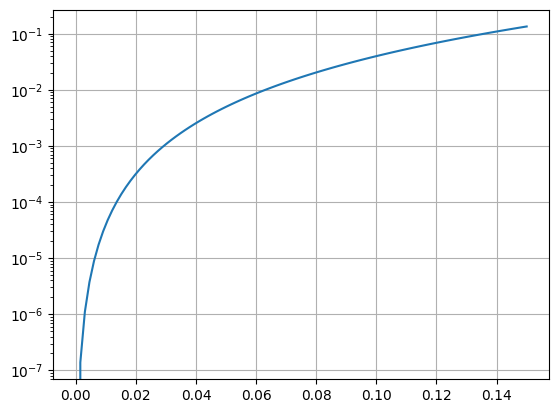

In [269]:
plt.plot(np.linspace(0, 0.15, 100), rho(32,np.linspace(0, 0.1, 100)))
plt.yscale('log')
plt.grid()

In [270]:
0.5**12-0.5**6

-0.015380859375

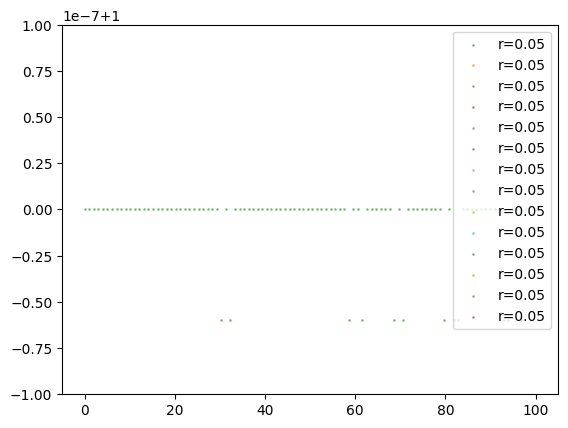

In [271]:
for i in range(len(dirs)):
    plt.scatter(timeLines[i], energies[i], label=f"r={rs[i]:.2f}", s=1, alpha=0.5)
plt.legend()
plt.ylim(0.9999999, 1.0000001)
plt.show()

In [272]:
np.linspace(0.1, 0.9, 9)

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

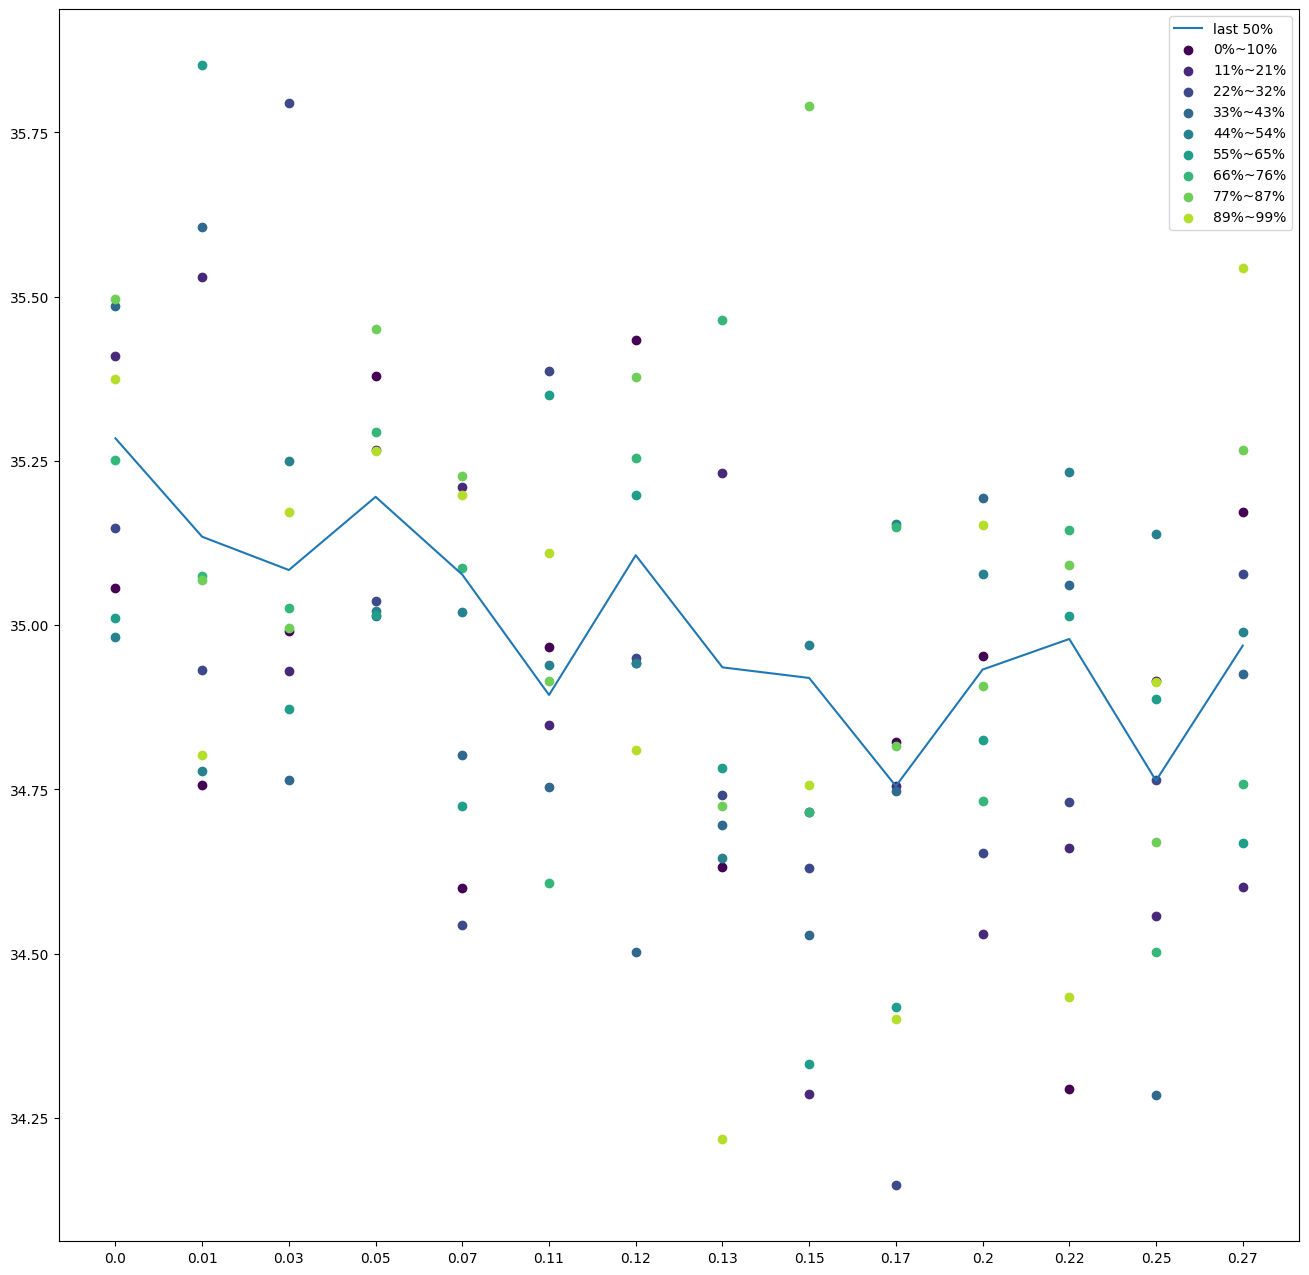

In [287]:
plt.figure(figsize=(16, 16))
# for rc in [0.8, 0.6, 0.5, 0.4, 0.2, 0.1, 0.07, 0.05]:
sorted_eps, sorted_pressures = zip(*sorted(zip(epsilons, [p[-int(len(p) * 0.5):].mean() for p in pressures])))
plt.plot([str(ep) for ep in sorted_eps], sorted_pressures, label=f"last {int(0.5*100)}%")
# plt.plot(sorted_eps, sorted_pressures, label=f"last {int(0.5*100)}%")
for rc in np.linspace(0.0, 0.89, 9):
    sorted_eps, sorted_pressures = zip(*sorted(zip(epsilons, [p[int(len(p) * rc):int(len(p) * (rc+0.1))].mean() for p in pressures])))
    plt.scatter([str(ep) for ep in sorted_eps], sorted_pressures, label=f"{int(rc*100)}%~{int((rc+0.1)*100)}%", color=plt.cm.viridis(rc))
    # plt.scatter(sorted_eps, sorted_pressures, label=f"{int(rc*100)}%~{int((rc+0.1)*100)}%")

# plt.scatter(epsilons, [p_per_Ts[i][-25:].mean() for i in range(len(dirs))])
# plt.grid()
plt.legend()
# plt.xlabel("LJ epsilon")
# plt.xscale('log')
# plt.xlim(0, 0.11)
# plt.ylim(38, 40)

In [274]:
1000000 / 100

10000.0

Text(0.5, 0, 'LJ epsilon')

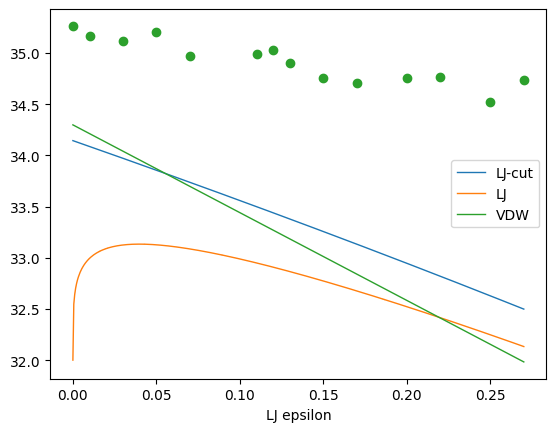

In [282]:
epss = np.linspace(0, max(epsilons), 500)
RADIUS = 0.05
cms = []
ces = []
for ep in epss:
    m, e = pressure_lj_cut(1.0, ep, RADIUS * 2, 32)
    cms.append(m / 1.0)
    ces.append(e * m)
cms = np.array(cms)
ces = np.array(ces)
plt.plot(epss, cms, label="LJ-cut", linewidth=1)
plt.fill_between(epss, cms-ces, cms+ces, alpha=0.5)
lms = []
les = []
for ep in epss:
    m, e = pressure_lj(1.0, ep, RADIUS * 2, 32)
    lms.append(m / 1.0)
    les.append(e * m)
lms = np.array(lms)
les = np.array(les)
plt.plot(epss, lms, label="LJ", linewidth=1)
plt.fill_between(epss, lms-les, lms+les, alpha=0.5)
plt.plot(epss, [vdw(1.0, ep, RADIUS * 2, 32) / 1.0 for ep in epss], label="VDW", linewidth=1)
plt.scatter(epsilons, [p_per_Ts[i].mean() for i in range(len(dirs))])
plt.legend()
plt.xlabel("LJ epsilon")
# plt.xscale('log')
# plt.xlim(0, 0.11)
# plt.ylim(48, 51)

In [276]:
[p[-int(len(p) * 0.5):].mean() for p in pressures]

[35.13452317372512,
 35.083936506829644,
 35.19531845931207,
 35.0768106907747,
 34.89374210576038,
 34.93575613243439,
 34.919616587532715,
 34.75504335871672,
 34.9323907180214,
 34.978955342897684,
 34.76335467955423,
 34.96873201506653,
 35.28436308668936,
 35.10641467669187]

C:\Users\hy-wu.DESKTOP-G355NC5\AppData\Local\Temp\ipykernel_11916\2546785980.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


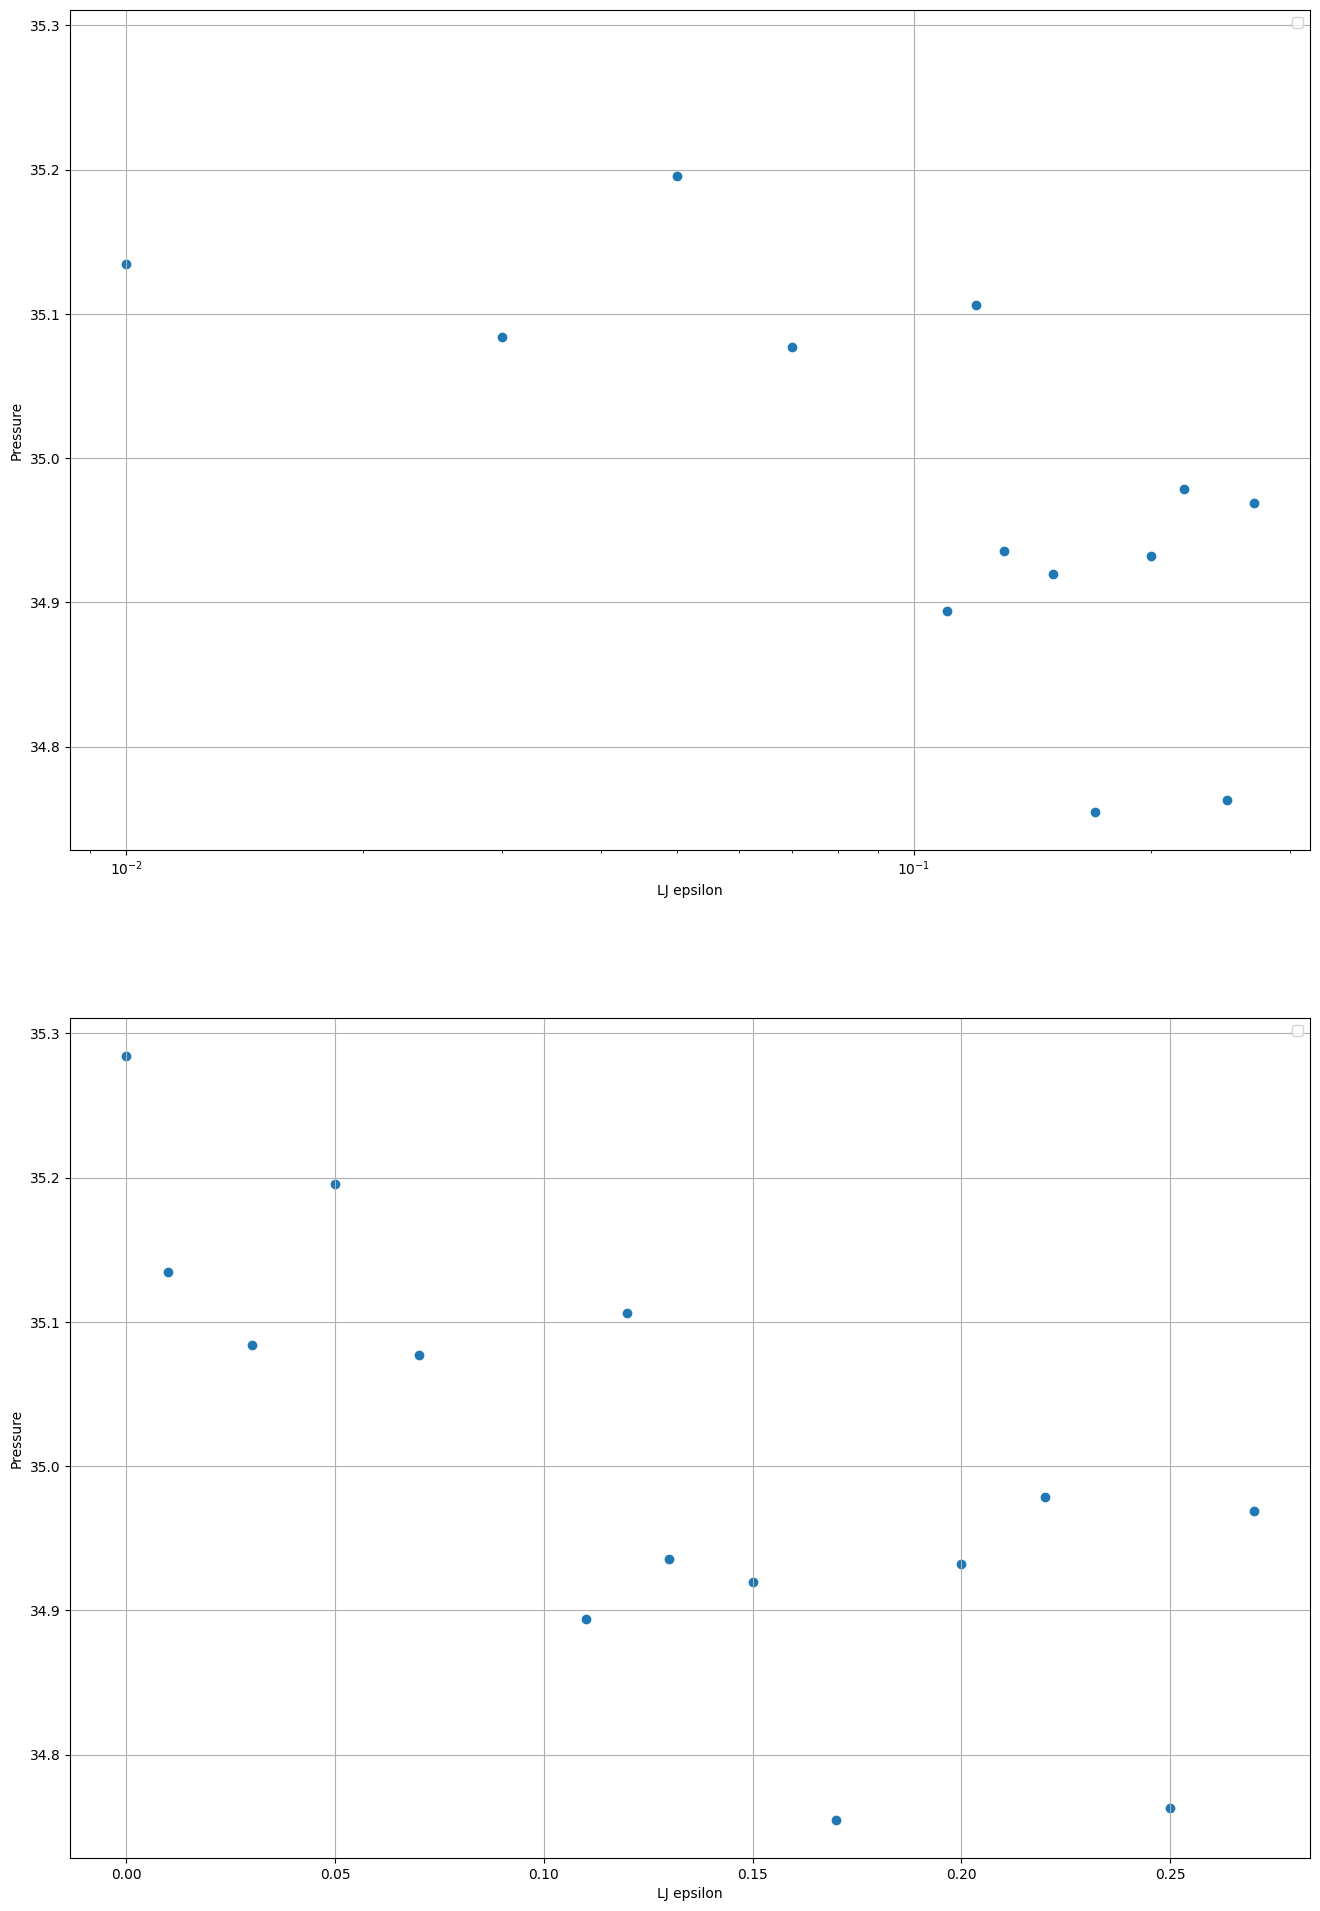

In [277]:
# rss = np.linspace(0, 0.18, 500)
# cms = []
# ces = []
# for r in rss:
#     m, e = pressure_lj_cut(1.0, 0, r * 2, 32)
#     cms.append(m)
#     ces.append(e * m)
# cms = np.array(cms)
# ces = np.array(ces)
# lms = []
# les = []
# for r in rss:
#     m, e = pressure_lj(1.0, 0, r * 2, 32)
#     lms.append(m)
#     les.append(e * m)
# lms = np.array(lms)
# les = np.array(les)
figs, axs = plt.subplots(2, 1, figsize=(16, 24))
for ax in axs:
    # ax.plot(rss, cms, label="LJ-cut", linewidth=1)
    # ax.fill_between(rss, cms-ces, cms+ces, alpha=0.5)
    # ax.plot(rss, lms, label="LJ", linewidth=1)
    # ax.fill_between(rss, lms-les, lms+les, alpha=0.5)
    # ax.plot(rss, [vdw(1.0, 0, r * 2, 32) for r in rss], label="VDW", linewidth=1)
    # ax.scatter(rs, [p[-25:].mean() for p in pressures])
    ax.scatter(epsilons, [p[-int(len(p) * 0.5):].mean() for p in pressures])
    ax.legend()
    ax.grid()
    ax.set_xlabel("LJ epsilon")
    ax.set_ylabel("Pressure")
# plt.yscale('log')
# axs[0].set_xlim(0, 0.18)
axs[0].set_xscale('log')
# axs[0].set_ylim(30, 140)
# axs[1].set_xlim(0, 0.11)
# axs[1].set_ylim(30, 50)

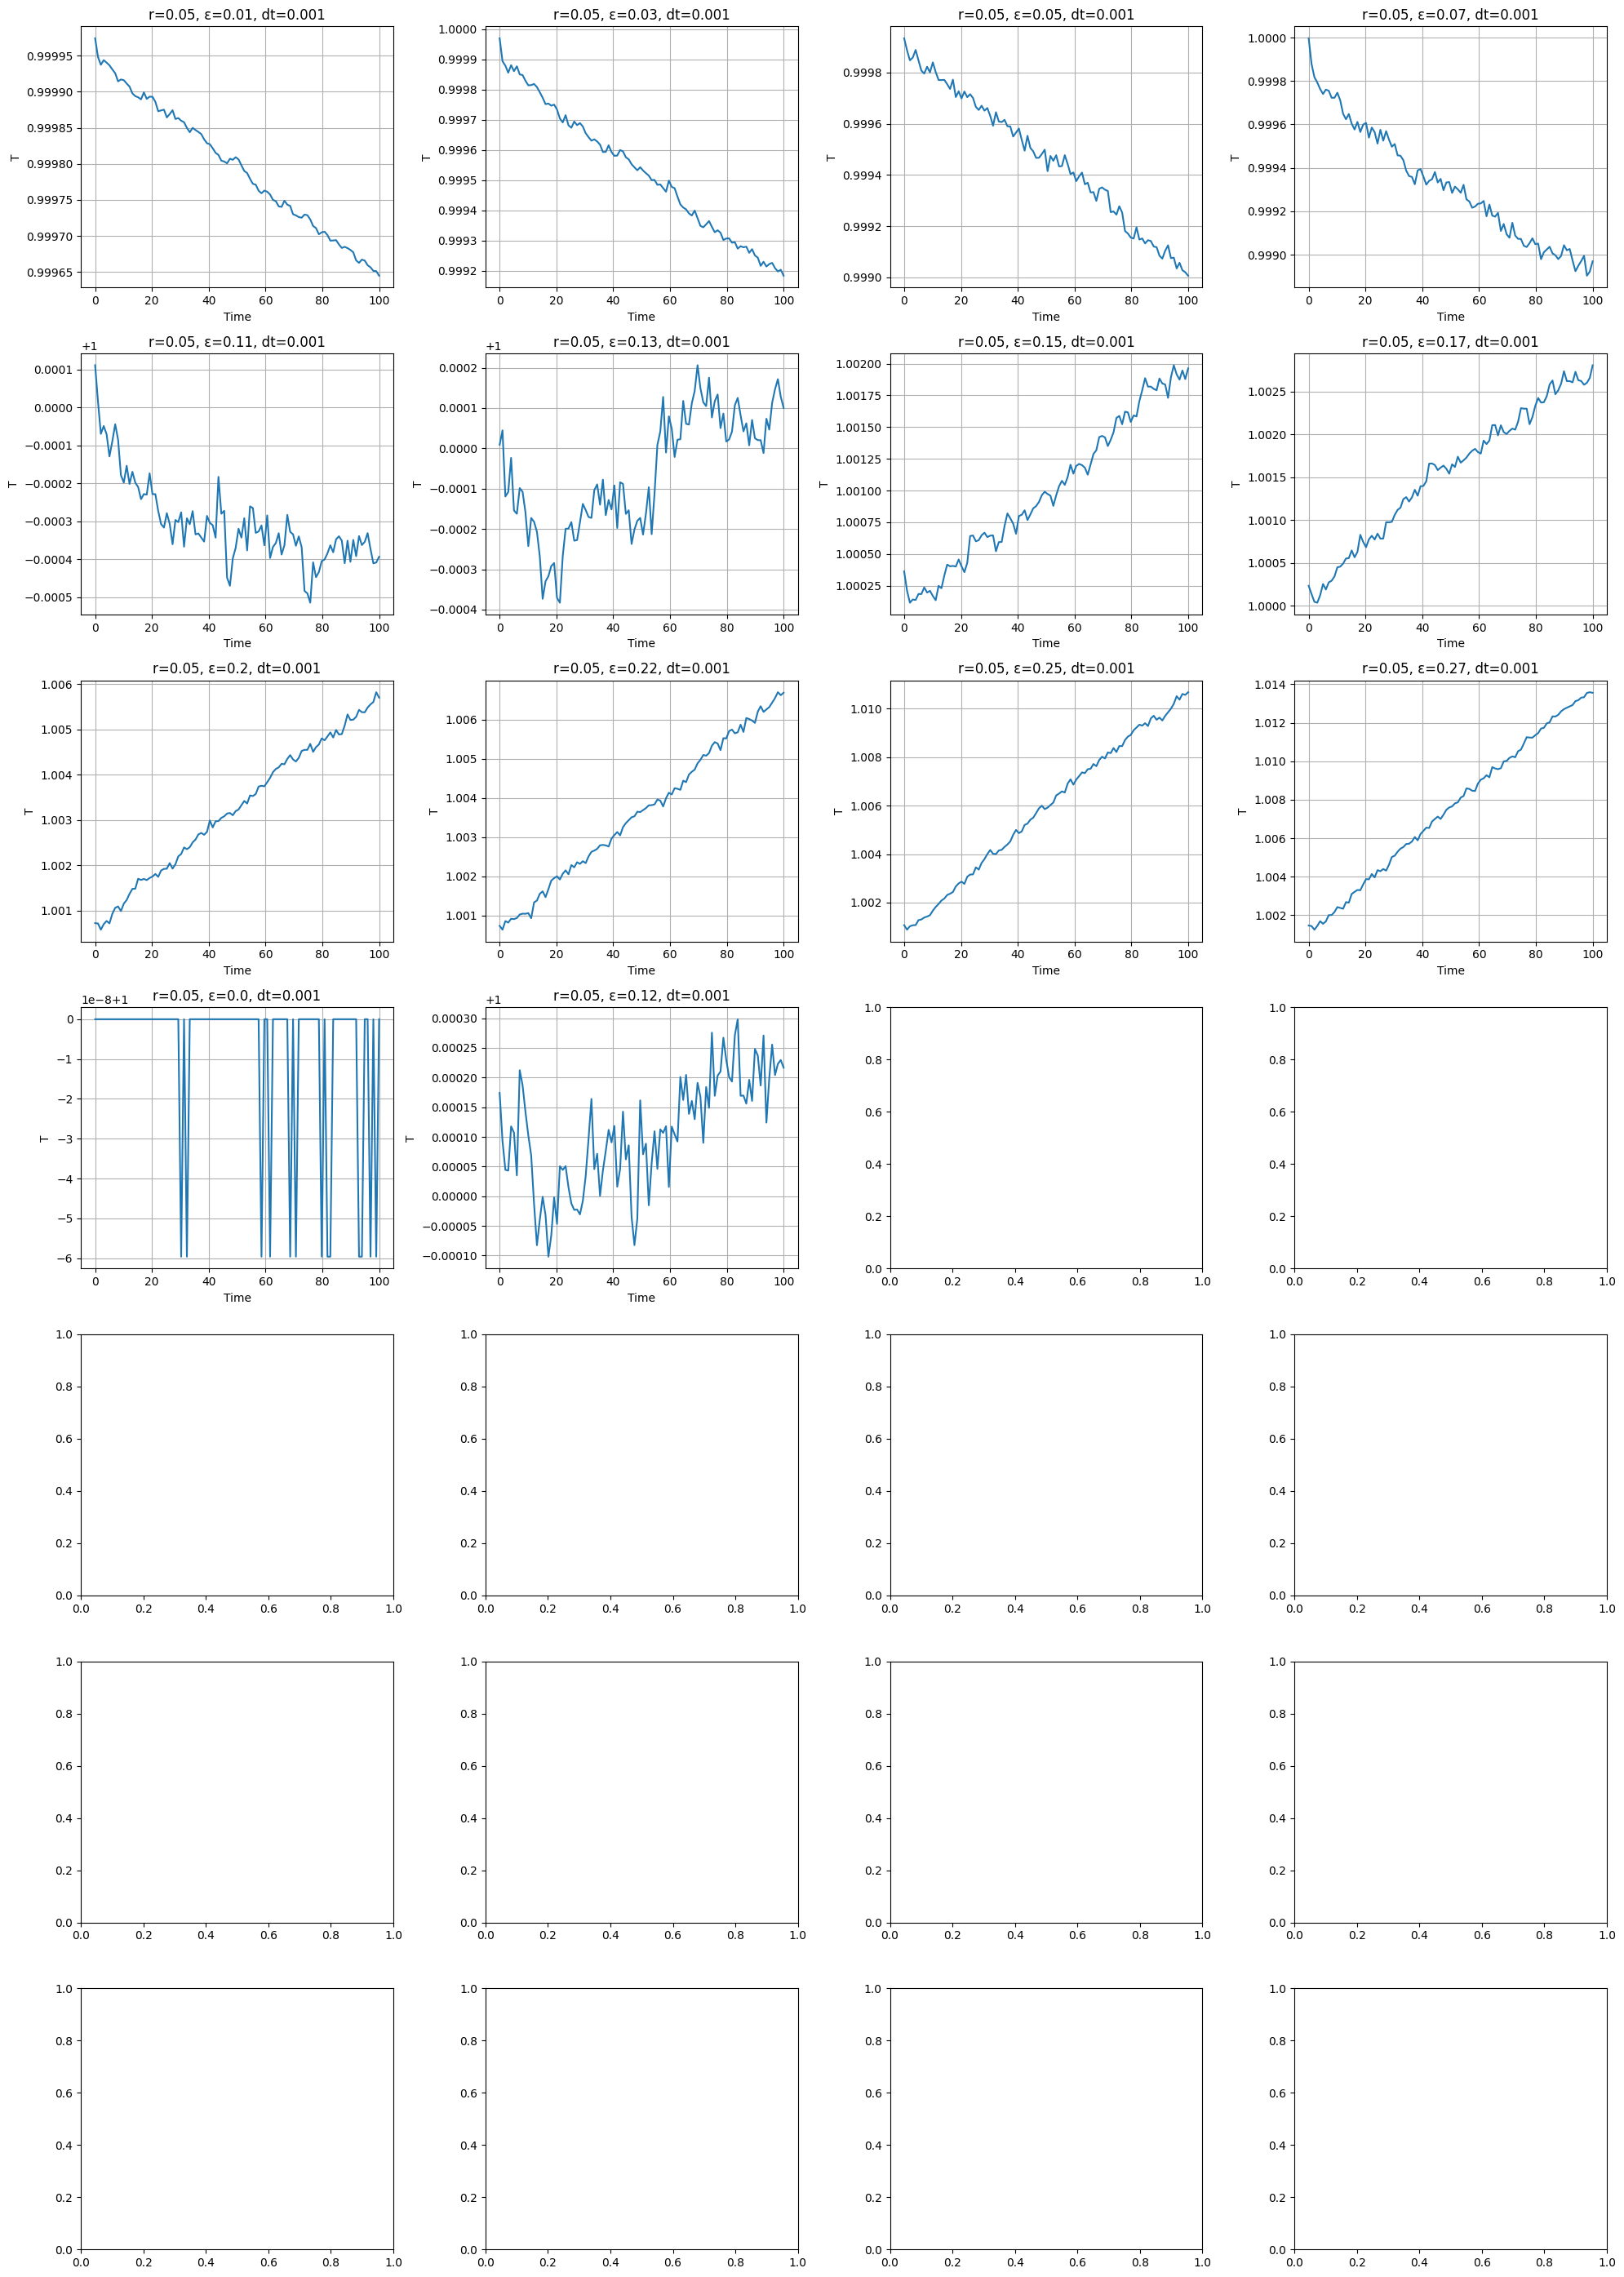

In [278]:
figs, axs = plt.subplots(7, 4, figsize=(20, 28))
for i, (e, r, ε, timeline, dt) in enumerate(zip(energies, rs, epsilons, timeLines, dts)):
    ax = axs[i // 4, i % 4]
    ax.plot(timeline, e)
    ax.set_title(f'r={r}, ε={ε}, dt={dt:.3f}')
    ax.set_xlabel('Time')
    ax.set_ylabel('T')
    ax.grid()

plt.tight_layout()
plt.show()

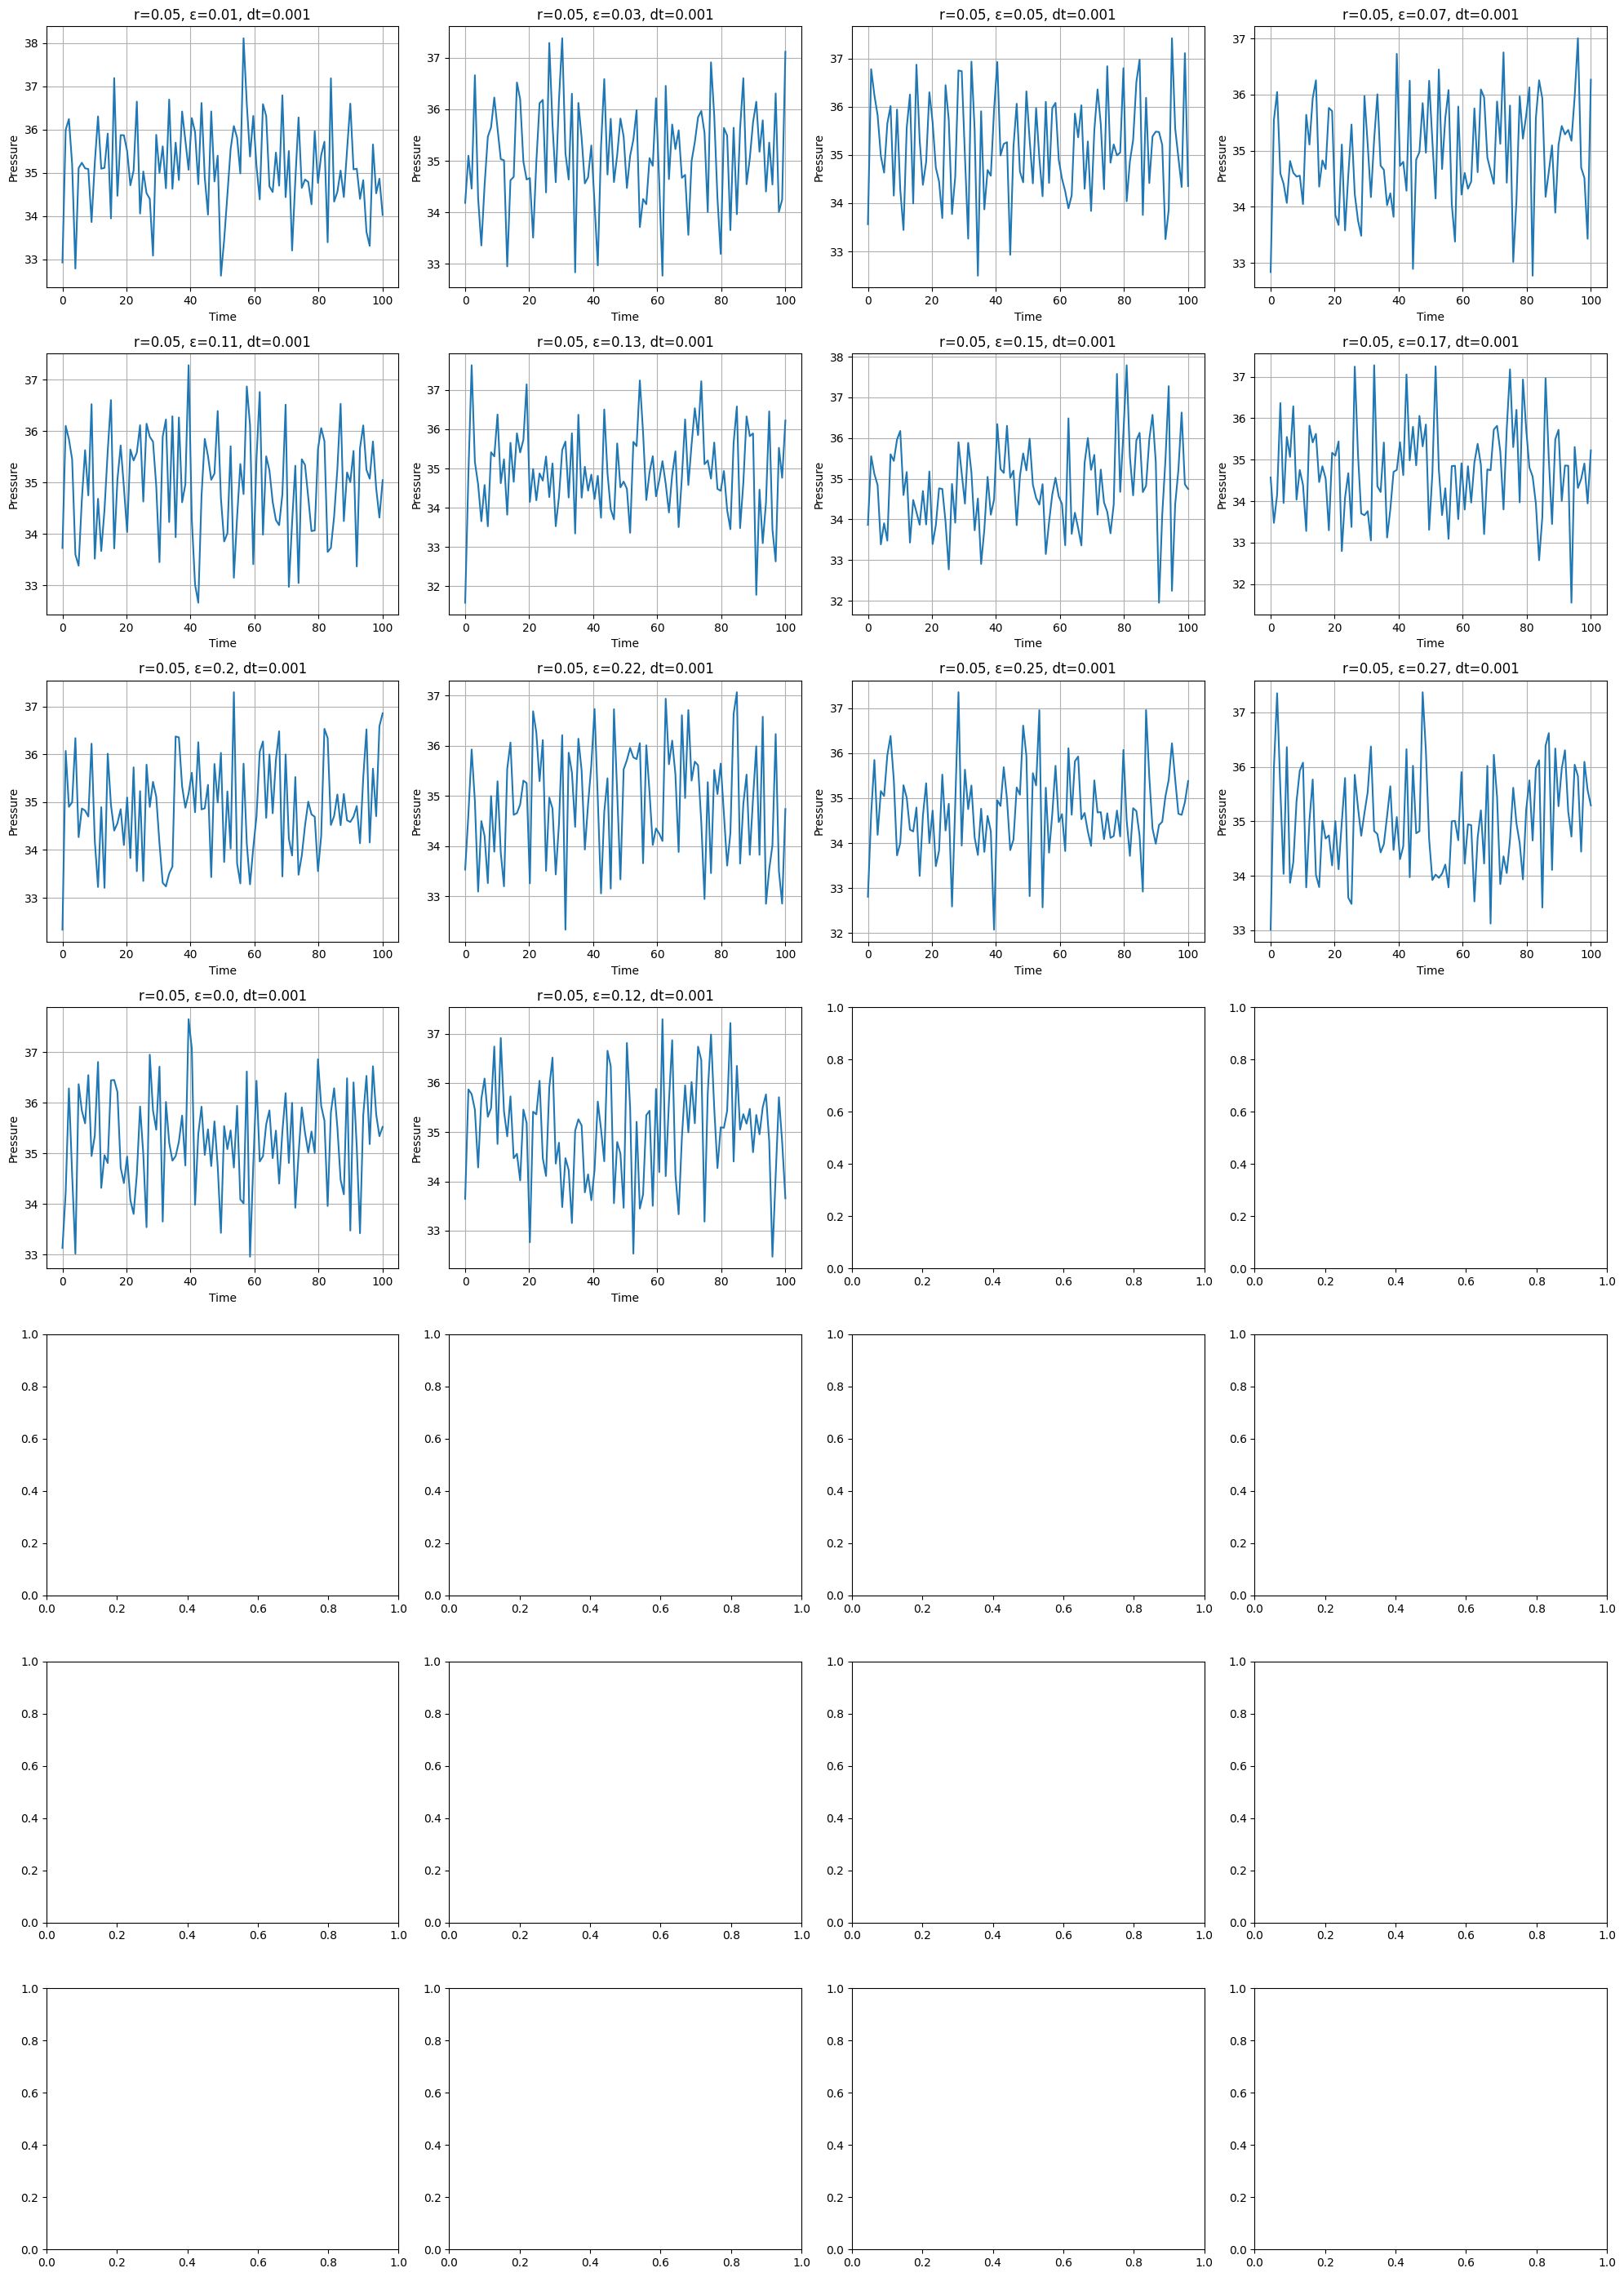

In [279]:
figs, axs = plt.subplots(7, 4, figsize=(20, 28))
for i, (p, r, ε, timeline, dt) in enumerate(zip(pressures, rs, epsilons, timeLines, dts)):
    ax = axs[i // 4, i % 4]
    ax.plot(timeline, p)
    ax.set_title(f'r={r}, ε={ε}, dt={dt:.3f}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Pressure')
    ax.grid()

plt.tight_layout()
plt.show()